# Portfolio Optimization Lab — Constrained Mean–Variance (CVXPY) with Rolling Out-of-Sample Backtest

**Goal.** Build and evaluate a constrained mean–variance allocator on liquid ETFs using a rolling out-of-sample protocol.
We compare against simple baselines (equal-weight, SPY), and we monitor constraints and turnover.

**Universe.** SPY, QQQ, IWM, TLT, GLD (daily).
**Key safeguards.** Rolling train window, periodic rebalancing, lagged weights (t−1), transaction costs via turnover.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from qmlab.data import load_prices_yf, compute_returns
from qmlab.optimizer import rolling_backtest_optimizer
from qmlab.backtest import backtest
from qmlab.metrics import summarize_performance, equity_curve, drawdown_series, turnover

tickers = ["SPY", "QQQ", "IWM", "TLT", "GLD"]
start, end = "2015-01-01", "2025-01-01"

## 1. Method overview

We solve a constrained mean–variance problem on a rolling basis:

\[
$\max_w \ \mu^\top w - \frac{\lambda}{2} w^\top \Sigma w$
\]

subject to:
- \($\sum_i w_i = 1$\)
- long-only: \($w_i \ge 0$\)
- weight cap: \($w_i \le w_{max}$\)
- turnover constraint (optional): \($\|w - w_{prev}\|_1 \le \tau$\)

**Backtest protocol.**
- Estimate \($\mu, \Sigma$\) on a trailing **train window** (e.g., 252 trading days)
- Rebalance every **rebalance_every** days (e.g., monthly ≈ 21)
- Apply weights with a **one-day lag** (t−1) to avoid lookahead
- Apply trading costs proportional to turnover (bps)

In [2]:
prices = load_prices_yf(tickers, start=start, end=end)
rets = compute_returns(prices, kind="simple").dropna()

pd.DataFrame({
    "start": [rets.index.min()],
    "end": [rets.index.max()],
    "n_days": [len(rets)],
    "avg_abs_ret": [float(rets.abs().mean().mean())],
})

,start,end,n_days,avg_abs_ret
0,2015-01-05,2024-12-31,2515,0.008137


**Data check.** We use daily returns from 2015-01-05 to 2024-12-31 (2515 trading days). The average absolute daily return is ~0.8%, which is consistent with a mixed ETF universe (equities + bonds + gold).

## 2. Experiment settings

Main run parameters:
- train window: 252 trading days
- rebalance: every 21 trading days
- costs: 5 bps × turnover
- risk_aversion (λ): 10
- long-only: True
- cap per asset: 0.5
- turnover limit (L1): 0.25

In [3]:
rp_opt, w_opt = rolling_backtest_optimizer(
    rets,
    train_days=252,
    rebalance_every=21,
    cost_bps=5.0,
    risk_aversion=10.0,
    long_only=True,
    w_max=0.5,
    turnover_limit=0.25,
)

# Baseline 1: equal-weight (no cost)
w_eq = pd.DataFrame(1/len(tickers), index=rets.index, columns=rets.columns)
rp_eq = backtest(rets, w_eq, cost_bps=0.0)

# Baseline 2: SPY buy&hold (no cost)
w_spy = pd.DataFrame(0.0, index=rets.index, columns=rets.columns)
w_spy["SPY"] = 1.0
rp_spy = backtest(rets, w_spy, cost_bps=0.0)

In [4]:
def row(name, rp, w):
    m = summarize_performance(rp)
    m["avg_turnover"] = float(turnover(w).mean())
    m["name"] = name
    return m

tbl = pd.DataFrame([
    row("Optimizer (rolling OOS, cost=5bps)", rp_opt, w_opt),
    row("Equal-Weight (daily, no cost)", rp_eq, w_eq),
    row("SPY buy&hold (no cost)", rp_spy, w_spy),
]).set_index("name")

tbl.round(4)

,annualized_return,annualized_vol,sharpe,max_drawdown,avg_turnover
name,,,,,
"Optimizer (rolling OOS, cost=5bps)",0.0861,0.1325,0.6896,-0.2737,0.01
"Equal-Weight (daily, no cost)",0.1007,0.1226,0.8436,-0.2555,0.00
SPY buy&hold (no cost),0.1324,0.1761,0.7946,-0.3372,0.00


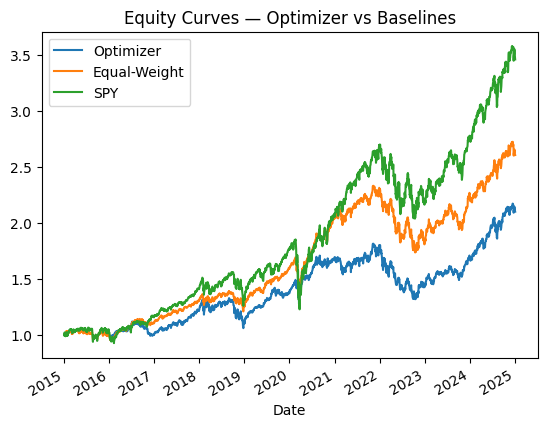

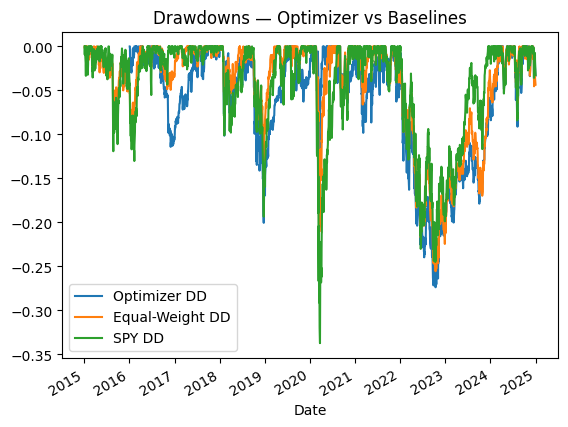

In [5]:
plt.figure()
equity_curve(rp_opt).plot(label="Optimizer")
equity_curve(rp_eq).plot(label="Equal-Weight")
equity_curve(rp_spy).plot(label="SPY")
plt.title("Equity Curves — Optimizer vs Baselines")
plt.legend()
plt.show()

plt.figure()
drawdown_series(rp_opt).plot(label="Optimizer DD")
drawdown_series(rp_eq).plot(label="Equal-Weight DD")
drawdown_series(rp_spy).plot(label="SPY DD")
plt.title("Drawdowns — Optimizer vs Baselines")
plt.legend()
plt.show()

## 4. Results (performance vs baselines)

After removing the warm-up period and forward-filling weights between rebalances, the constrained rolling mean–variance optimizer delivers an annualized return of ~8.6% with ~13.3% volatility (Sharpe ~0.69) and max drawdown ~−27%. Average turnover is very low (~0.01), indicating stable allocations and limited sensitivity to trading frictions even when applying 5 bps costs.

Equal-weight remains a strong benchmark on this small ETF universe (higher return and Sharpe on this sample), while SPY buy-and-hold achieves higher return but at materially higher volatility and deeper drawdowns. The optimizer therefore provides a more constrained, risk-controlled allocation, but does not outperform the equal-weight benchmark over 2015–2024.

### Equity curves and drawdowns

The equity curves confirm that the decade-long sample is favorable to long equity exposure: SPY compounds the most but with the largest drawdowns. Equal-weight delivers strong compounding with a more diversified profile. The rolling constrained optimizer produces a smoother, more conservative growth path but underperforms both baselines in cumulative return.

Drawdowns highlight the key trade-off: the optimizer avoids the deepest equity-only drawdowns (relative to SPY), but its maximum drawdown is similar to the equal-weight benchmark, particularly during the 2022–2023 regime where portfolio dynamics and estimated covariances/returns likely shift.

## 3. Constraints sanity checks

We verify that the realized weights respect the main constraints:
- weights sum to 1 (numerical tolerance)
- long-only (min weight ≥ 0)
- cap constraint (max weight ≤ w_max)
- turnover distribution is reasonable and consistent with the turnover limit

In [6]:
w_stats = pd.DataFrame({
    "sum_w": w_opt.sum(axis=1),
    "min_w": w_opt.min(axis=1),
    "max_w": w_opt.max(axis=1),
    "turnover": turnover(w_opt),
})

w_stats.describe().round(4)

,sum_w,min_w,max_w,turnover
count,2263.0,2263.0000,2263.0000,2263.0000
mean,1.0,0.0042,0.4702,0.0100
std,0.0,0.0206,0.0530,0.0475
min,1.0,0.0000,0.2704,0.0000
25%,1.0,0.0000,0.4403,0.0000
50%,1.0,0.0000,0.5000,0.0000
75%,1.0,0.0000,0.5000,0.0000
max,1.0,0.1250,0.5000,0.2500


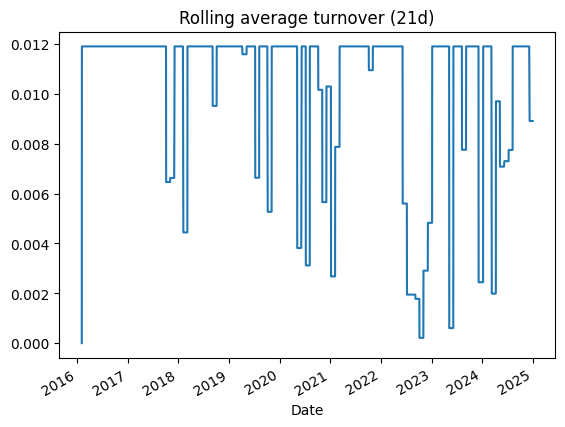

In [7]:
plt.figure()
w_stats["turnover"].rolling(21).mean().plot()
plt.title("Rolling average turnover (21d)")
plt.show()

## 3. Constraints sanity checks

The realized weights satisfy the main constraints throughout the active backtest period:
- fully invested: sum of weights is consistently 1
- long-only: minimum weight is 0
- cap constraint: maximum weight never exceeds 0.5 and is often binding
- turnover constraint: turnover remains low on average and never exceeds the specified limit (0.25)

This confirms the optimizer implementation behaves as intended, producing stable allocations with controlled trading.

## 6. Conclusion

This notebook implemented a constrained mean–variance allocator (CVXPY) and evaluated it using a rolling out-of-sample protocol on a small ETF universe (SPY, QQQ, IWM, TLT, GLD). The constraint diagnostics confirm the optimizer behaves as intended: the portfolio stays fully invested, remains long-only, respects the 0.5 weight cap (often binding), and keeps turnover tightly controlled (never exceeding the turnover limit).

In terms of performance, the optimizer delivers a reasonable risk-adjusted profile with low trading activity and explicit control of allocation stability. However, on this 2015–2024 sample, simple long-only benchmarks—especially equal-weight—remain difficult to beat, highlighting how strong naïve diversification can be in a small universe and how sensitive mean–variance optimization is to estimation error in expected returns and covariances.

**Key takeaway.** The main value of the constrained optimizer here is *stability and implementability* (low turnover, enforced caps), rather than outperforming a strong equal-weight baseline.

**Next steps.**
1) Improve estimation: covariance shrinkage (e.g., Ledoit–Wolf) and/or robust mean estimates.  
2) Add stronger baselines: minimum-variance and risk parity, and compare fairly under the same cost model.  
3) Tune constraints walk-forward (risk_aversion, turnover limit, caps) and analyze regime sensitivity (e.g., 2020 vs 2022).